<a href="https://colab.research.google.com/github/Muqeem-Ahmed/Data-Visualization-Lab/blob/main/A2_u2023331_u2023561.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 0. Imports and Setup
This section imports all necessary libraries for data manipulation, visualization, and statistical analysis. It also includes settings for warnings and plot styles.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import kagglehub
import os

### 1. Data Loading and Overview Function
This function (`load_and_overview_data`) is designed to load the dataset from a specified file path and provide an initial comprehensive overview. It checks the dataset's shape, displays the first few rows, shows data types, provides statistical summaries for numerical columns, lists missing values, and gives an overview of categorical features.

In [ ]:
def load_and_overview_data(filepath):
    """
    Load the dataset and provide a thorough overview of its structure and content.
    """
    print("=" * 80)
    print("1. DATA LOADING AND OVERVIEW")
    print("=" * 80)

    # Load the dataset
    df = pd.read_csv(filepath)
    print(f"\n✓ Dataset loaded successfully!")
    print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

    # Display first few rows
    print("\n--- First 5 Rows ---")
    print(df.head())

    # Data types
    print("\n--- Data Types ---")
    print(df.dtypes)

    # Data Info
    print("\n--- Dataset Info ---")
    df.info()

    # Statistical Summary
    print("\n--- Numerical Columns Summary Statistics ---")
    print(df.describe())

    # Missing Values
    print("\n--- Missing Values ---")
    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(missing_data)

    # Categorical columns overview
    print("\n--- Categorical Columns Overview ---")
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts())

    return df

### 2. Data Preprocessing Function
This function (`data_preprocessing`) handles various data cleaning and preparation tasks. It includes steps for managing missing values, converting data types, removing duplicate records, standardizing categorical variables, detecting outliers, and engineering new features like salary ranges and remote work categories. It concludes with a data validation summary.

In [ ]:
def data_preprocessing(df):
    """
    Perform comprehensive data preprocessing including:
    - Handling missing values
    - Data type conversion
    - Outlier detection and treatment
    - Feature engineering
    - Data validation
    """
    print("\n" + "=" * 80)
    print("2. DATA PREPROCESSING")
    print("=" * 80)

    df_processed = df.copy()

    # ---- 2.1: Check for Missing Values ----
    print("\n--- Handling Missing Values ---")
    missing_count = df_processed.isnull().sum().sum()
    print(f"Total missing values: {missing_count}")

    if missing_count > 0:
        print("Columns with missing values:")
        print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])
        # Fill or drop based on strategy (adjust as needed)
        df_processed = df_processed.dropna()
        print("✓ Missing values handled")
    else:
        print("✓ No missing values found")

    # ---- 2.2: Data Type Conversion ----
    print("\n--- Data Type Conversion ---")
    # Convert work_year to int if it's numeric
    if df_processed['work_year'].dtype == 'object':
        df_processed['work_year'] = pd.to_numeric(df_processed['work_year'], errors='coerce')

    # Ensure salary columns are numeric
    df_processed['salary'] = pd.to_numeric(df_processed['salary'], errors='coerce')
    df_processed['salary_in_usd'] = pd.to_numeric(df_processed['salary_in_usd'], errors='coerce')
    df_processed['remote_ratio'] = pd.to_numeric(df_processed['remote_ratio'], errors='coerce')

    print("✓ Data types converted")

    # ---- 2.3: Duplicate Records ----
    print("\n--- Handling Duplicates ---")
    duplicate_count = df_processed.duplicated().sum()
    print(f"Duplicate records found: {duplicate_count}")
    if duplicate_count > 0:
        df_processed = df_processed.drop_duplicates()
        print("✓ Duplicates removed")

    # ---- 2.4: Standardize Categorical Variables ----
    print("\n--- Standardizing Categorical Variables ---")

    # Strip whitespace from object columns
    for col in df_processed.select_dtypes(include=['object']).columns:
        df_processed[col] = df_processed[col].str.strip()

    print("✓ Whitespace removed from categorical variables")

    # ---- 2.5: Outlier Detection ----
    print("\n--- Outlier Detection ---")
    numerical_cols = ['salary', 'salary_in_usd', 'remote_ratio']

    outliers_info = {}
    for col in numerical_cols:
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_mask = (df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)
        outlier_count = outlier_mask.sum()
        outliers_info[col] = outlier_count

        print(f"{col}: {outlier_count} outliers detected (bounds: {lower_bound:.2f} - {upper_bound:.2f})")

    print("✓ Outliers identified (kept for analysis - review before removal)")

    # ---- 2.6: Feature Engineering ----
    print("\n--- Feature Engineering ---")

    # Salary range categories
    df_processed['salary_usd_range'] = pd.cut(
        df_processed['salary_in_usd'],
        bins=[0, 50000, 100000, 150000, 200000, float('inf')],
        labels=['<50K', '50K-100K', '100K-150K', '150K-200K', '>200K']
    )

    # Remote work categories
    df_processed['remote_category'] = pd.cut(
        df_processed['remote_ratio'],
        bins=[-0.1, 0, 50, 100],
        labels=['Full Office', 'Hybrid', 'Full Remote']
    )

    # Log transformation for 'salary_in_usd'
    df_processed['salary_in_usd_log'] = np.log1p(df_processed['salary_in_usd'])
    print("✓ Log transformation applied to 'salary_in_usd'")

    print("✓ Salary range categories created")
    print("✓ Remote work categories created")

    # ---- 2.7: Encoding Categorical Variables (for future modeling) ----
    print("\n--- Categorical Variable Encoding (Reference) ---")
    print("\nCategorical columns and their unique values:")
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        unique_vals = df_processed[col].unique()
        print(f"\n{col} ({len(unique_vals)} unique):")
        for i, val in enumerate(unique_vals[:10], 1):
            print(f"  {i}. {val}")
        if len(unique_vals) > 10:
            print(f"  ... and {len(unique_vals) - 10} more")

    # ---- 2.8: Data Validation ----
    print("\n--- Data Validation ---")
    print(f"Rows after preprocessing: {len(df_processed)}")
    print(f"Columns: {df_processed.shape[1]}")
    print(f"Missing values: {df_processed.isnull().sum().sum()}")
    print("✓ Preprocessing complete!")

    return df_processed

### 3. Exploratory Data Analysis (EDA) Function
This function (`exploratory_data_analysis`) performs an in-depth EDA, including numerical and categorical analysis, correlation analysis, and generating various visualizations. It saves the visualizations as PNG files and prints detailed insights derived from the plots and data statistics, culminating in strategic business recommendations.

In [ ]:
def exploratory_data_analysis(df):
    """
    Perform comprehensive exploratory data analysis with visualizations.
    """
    print("\n" + "=" * 80)
    print("3. EXPLORATORY DATA ANALYSIS (EDA)")
    print("=" * 80)

    # Set visualization style
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (12, 6)

    # ---- 3.1: NUMERICAL ANALYSIS ----
    print("\n--- 3.1: NUMERICAL COLUMNS ANALYSIS ---")

    numerical_cols = df.select_dtypes(include=[np.number]).columns
    print(f"\nNumerical columns: {list(numerical_cols)}")

    for col in numerical_cols:
        print(f"\n{col}:")
        print(f"  Mean: ${df[col].mean():,.2f}")
        print(f"  Median: ${df[col].median():,.2f}")
        print(f"  Std Dev: ${df[col].std():,.2f}")
        print(f"  Min: ${df[col].min():,.2f}")
        print(f"  Max: ${df[col].max():,.2f}")
        print(f"  Skewness: {stats.skew(df[col]):.3f}")
        print(f"  Kurtosis: {stats.kurtosis(df[col]):.3f}")

    # ---- 3.2: CATEGORICAL ANALYSIS ----
    print("\n--- 3.2: CATEGORICAL COLUMNS ANALYSIS ---")

    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Most common: {df[col].value_counts().index[0]} ({df[col].value_counts().values[0]} occurrences)")
        print(f"  Distribution:")
        print(df[col].value_counts().head(10))

    # ---- 3.3: CORRELATION ANALYSIS ----
    print("\n--- 3.3: CORRELATION ANALYSIS ---")

    numeric_df = df.select_dtypes(include=[np.number])
    correlation_matrix = numeric_df.corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)

    # Find strong correlations
    print("\nStrong Correlations (|r| > 0.5):")
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                strong_corr.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': correlation_matrix.iloc[i, j]
                })

    if strong_corr:
        corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', ascending=False)
        print(corr_df.to_string(index=False))
    else:
        print("No strong correlations found")

    # ---- 3.4: CREATE VISUALIZATIONS ----
    print("\n--- 3.4: GENERATING VISUALIZATIONS ---")

    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))

    # 1. Salary Distribution (Log Transformed)
    ax1 = plt.subplot(2, 3, 1)
    df['salary_in_usd_log'].hist(bins=30, edgecolor='black', ax=ax1)
    ax1.set_title('Distribution of Log-Transformed Salary (USD)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Log(Salary in USD)')
    ax1.set_ylabel('Frequency')

    # 2. Salary by Experience Level
    ax2 = plt.subplot(2, 3, 2)
    df.boxplot(column='salary_in_usd', by='experience_level', ax=ax2)
    ax2.set_title('Salary by Experience Level', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Experience Level')
    ax2.set_ylabel('Salary (USD)')
    plt.sca(ax2)
    plt.xticks(rotation=45)

    # 3. Salary by Job Title (Top 10)
    ax3 = plt.subplot(2, 3, 3)
    top_jobs = df['job_title'].value_counts().head(10).index
    df[df['job_title'].isin(top_jobs)].groupby('job_title')['salary_in_usd'].mean().sort_values().plot(kind='barh', ax=ax3)
    ax3.set_title('Average Salary by Job Title (Top 10)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Average Salary (USD)')

    # 4. Remote Ratio Distribution (moved to take the place of the removed pie chart)
    ax4 = plt.subplot(2, 3, 4)
    df['remote_ratio'].value_counts().sort_index().plot(kind='bar', ax=ax4, color='skyblue')
    ax4.set_title('Remote Work Distribution', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Remote Ratio (%)')
    ax4.set_ylabel('Count')
    plt.sca(ax4)
    plt.xticks(rotation=0)

    # 5. Company Size Distribution (moved from 6 to 5)
    ax5 = plt.subplot(2, 3, 5)
    size_order = df['company_size'].value_counts().sort_values(ascending=False)
    size_order.plot(kind='bar', ax=ax5, color='lightcoral')
    ax5.set_title('Company Size Distribution', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Company Size')
    ax5.set_ylabel('Count')
    plt.sca(ax5)
    plt.xticks(rotation=0)

    # Placeholder for the sixth subplot or adjust layout if fewer subplots are desired
    # If you intend to add another plot, use ax6 = plt.subplot(2, 3, 6) here
    # Or, change fig = plt.figure(figsize=(16, 12)) and subplots to (2,2) or (2,2) and (1,2) for example

    plt.tight_layout()
    plt.savefig('eda_visualizations_1.png', dpi=300, bbox_inches='tight')
    print("✓ Visualization 1 saved: eda_visualizations_1.png")
    plt.show()

    # Additional visualizations
    fig2 = plt.figure(figsize=(16, 10))

    # 7. Salary by Company Size
    ax7 = plt.subplot(2, 3, 1)
    df.boxplot(column='salary_in_usd', by='company_size', ax=ax7)
    ax7.set_title('Salary by Company Size', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Company Size')
    ax7.set_ylabel('Salary (USD)')

    # 8. Salary by Remote Ratio
    ax8 = plt.subplot(2, 3, 2)
    remote_salary_avg = df.groupby('remote_ratio')['salary_in_usd'].mean().sort_values()
    remote_salary_avg.plot(kind='bar', ax=ax8, color='mediumseagreen')
    ax8.set_title('Average Salary by Remote Work Ratio', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Remote Ratio (%)')
    ax8.set_ylabel('Average Salary (USD)')
    plt.sca(ax8)
    plt.xticks(rotation=0)

    # 9. Work Year Trends
    ax9 = plt.subplot(2, 3, 3)
    df.groupby('work_year')['salary_in_usd'].mean().plot(kind='line', marker='o', ax=ax9, linewidth=2, markersize=8)
    ax9.set_title('Salary Trend Over Years', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Work Year')
    ax9.set_ylabel('Average Salary (USD)')
    ax9.grid(True, alpha=0.3)

    # 10. Correlation Heatmap
    ax10 = plt.subplot(2, 3, 4)
    numeric_cols_for_heatmap = ['work_year', 'salary', 'salary_in_usd_log', 'remote_ratio'] # Updated for log-transformed salary
    corr_subset = df[numeric_cols_for_heatmap].corr()
    sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax10, cbar_kws={'label': 'Correlation'})
    ax10.set_title('Correlation Heatmap (with Log-transformed Salary)', fontsize=12, fontweight='bold') # Updated title

    # 11. Top 15 Countries
    ax11 = plt.subplot(2, 3, 5)
    top_countries = df['employee_residence'].value_counts().head(15)
    top_countries.plot(kind='barh', ax=ax11, color='mediumpurple')
    ax11.set_title('Top 15 Countries by Employee Count', fontsize=12, fontweight='bold')
    ax11.set_xlabel('Count')

    # 12. Salary Currency Distribution
    ax12 = plt.subplot(2, 3, 6)
    top_currencies = df['salary_currency'].value_counts().head(10)
    top_currencies.plot(kind='bar', ax=ax12, color='gold')
    ax12.set_title('Top 10 Salary Currencies', fontsize=12, fontweight='bold')
    ax12.set_ylabel('Count')
    plt.sca(ax12)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig('eda_visualizations_2.png', dpi=300, bbox_inches='tight')
    print("✓ Visualization 2 saved: eda_visualizations_2.png")
    plt.show()

    # ---- 3.5: KEY INSIGHTS ----
    print("\n--- 3.5: KEY INSIGHTS ---")

    print(f"\n📊 Dataset Overview:")
    print(f"  • Total records: {len(df):,}")
    print(f"  • Time period: {df['work_year'].min()} - {df['work_year'].max()}")
    print(f"  • Countries represented: {df['employee_residence'].nunique()}")
    print(f"  • Job titles: {df['job_title'].nunique()}")

    print(f"\n💰 Salary Insights:")
    print(f"  • Average salary (USD): ${df['salary_in_usd'].mean():,.2f}")
    print(f"  • Median salary (USD): ${df['salary_in_usd'].median():,.2f}")
    print(f"  • Salary range: ${df['salary_in_usd'].min():,.0f} - ${df['salary_in_usd'].max():,.0f}")
    print(f"  • Highest paying job: {df.loc[df['salary_in_usd'].idxmax(), 'job_title']}")
    print(f"  • Highest paying country: {df.groupby('employee_residence')['salary_in_usd'].mean().idxmax()}")

    print(f"\n👔 Employment Insights:")
    print(f"  • Most common role: {df['job_title'].value_counts().index[0]}")
    print(f"  • Full-time employees: {(df['employment_type'] == 'FT').sum()} ({(df['employment_type'] == 'FT').sum()/len(df)*100:.1f}%)")
    print(f"  • Remote work ratio: {df['remote_ratio'].mean():.0f}% (average)")
    print(f"  • Most common company size: {df['company_size'].value_counts().index[0]}")

    print(f"\n🏂 Company Insights:")
    highest_avg_salary = df.groupby('company_size')['salary_in_usd'].mean()
    print(f"  • Highest average salary by size: {highest_avg_salary.idxmax()} (${highest_avg_salary.max():,.0f})")

    # ---- 3.6: DETAILED VISUALIZATION INSIGHTS ----
    print("\n" + "=" * 80)
    print("3.6: DETAILED INSIGHTS FROM VISUALIZATIONS")
    print("=" * 80)

    # Visualization 1 Insights
    print("\n--- VISUALIZATION 1: SALARY DISTRIBUTION & DEMOGRAPHICS ---")

    print("\n1‼️ Distribution of Log-Transformed Salary (USD):")
    salary_log_skew = stats.skew(df['salary_in_usd_log'])
    percentile_25_log = df['salary_in_usd_log'].quantile(0.25)
    percentile_75_log = df['salary_in_usd_log'].quantile(0.75)
    print(f"   • The log-transformed distribution shows a {'right-skewed (positively skewed)' if salary_log_skew > 0.5 else 'relatively balanced'} pattern")
    print(f"   • Skewness coefficient (log-transformed): {salary_log_skew:.3f}")
    print(f"   • 25th percentile (log-transformed): {percentile_25_log:.2f}")
    print(f"   • 75th percentile (log-transformed): {percentile_75_log:.2f}")
    print(f"   • Interquartile range (IQR) (log-transformed): {percentile_75_log - percentile_25_log:.2f}")
    print(f"   • Interpretation: Log transformation has helped to normalize the salary distribution,")
    print(f"     making it more suitable for models that assume normal distribution.")

    print("\n2‼️ Salary by Experience Level:")
    exp_levels = df.groupby('experience_level')['salary_in_usd'].agg(['count', 'mean', 'median', 'min', 'max'])
    print(f"   Experience Level Breakdown:")
    for idx in exp_levels.index:
        count, mean_sal, median_sal, min_sal, max_sal = exp_levels.loc[idx]
        print(f"   • {idx}: {int(count)} employees")
        print(f"     - Average: ${mean_sal:,.0f} | Median: ${median_sal:,.0f}")
        print(f"     - Range: ${min_sal:,.0f} - ${max_sal:,.0f}")

    salary_by_exp = df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False)
    print(f"\n   Key Finding: There's a clear salary progression with experience.")
    print(f"   The highest-paid level ({salary_by_exp.index[0]}) earns approximately")
    print(f"   {salary_by_exp.iloc[0]/salary_by_exp.iloc[-1]:.1f}x more than the lowest-paid level ({salary_by_exp.index[-1]}).")

    print("\n3‼️ Average Salary by Job Title (Top 10):")
    top_salary_jobs = df.groupby('job_title')['salary_in_usd'].mean().nlargest(10)
    print(f"   Highest-Paying Roles:")
    for i, (job, salary) in enumerate(top_salary_jobs.items(), 1):
        count = len(df[df['job_title'] == job])
        print(f"   {i}. {job}: ${salary:,.0f} ({count} positions)")

    # 4. Remote Work Distribution has moved to ax4 (was 5)
    print("\n4‼️ Remote Work Distribution:")
    remote_dist = df['remote_ratio'].value_counts().sort_index()
    print(f"   Remote Work Breakdown:")
    for ratio in sorted(df['remote_ratio'].unique()):
        count = (df['remote_ratio'] == ratio).sum()
        pct = count / len(df) * 100
        remote_type = "Full Remote" if ratio == 100 else "Hybrid/Flexible" if ratio == 50 else "On-site/No Remote"
        print(f"   • {ratio}% Remote ({remote_type}): {count} employees ({pct:.1f}%)")

    avg_remote = df['remote_ratio'].mean()
    print(f"\n   Average Remote Ratio: {avg_remote:.1f}%")
    full_remote_pct = (df['remote_ratio'] == 100).sum() / len(df) * 100
    print(f"   Full Remote Positions: {full_remote_pct:.1f}%")
    print(f"   Insight: A significant portion of roles offer remote flexibility,")
    print(f"   reflecting the industry's shift toward flexible work arrangements.")

    # 5. Company Size Distribution has moved to ax5 (was 6)
    print("\n5‼️ Company Size Distribution:")
    size_dist = df['company_size'].value_counts()
    print(f"   • Small (S): {size_dist.get('S', 0)} ({size_dist.get('S', 0)/len(df)*100:.1f}%)")
    print(f"   • Medium (M): {size_dist.get('M', 0)} ({size_dist.get('M', 0)/len(df)*100:.1f}%)")
    print(f"   • Large (L): {size_dist.get('L', 0)} ({size_dist.get('L', 0)/len(df)*100:.1f}%)")
    print(f"\n   Insight: Mid and large companies dominate the market, likely because")
    print(f"   they have more resources to invest in data science teams.")

    # Visualization 2 Insights
    print("\n--- VISUALIZATION 2: ADVANCED ANALYSIS & TRENDS ---")

    print("\n6‼️ Salary by Company Size:")
    salary_by_size = df.groupby('company_size')['salary_in_usd'].agg(['mean', 'median', 'count'])
    print(f"   Company Size Impact on Salary:")
    for size in salary_by_size.index:
        mean_sal, median_sal, count = salary_by_size.loc[size]
        print(f"   • {size} (n={int(count)}): Mean=${mean_sal:,.0f}, Median=${median_sal:,.0f}")

    salary_range = salary_by_size['mean'].max() - salary_by_size['mean'].min()
    print(f"\n   Salary Variance Across Sizes: ${salary_range:,.0f}")
    print(f"   Key Insight: Larger companies generally offer higher salaries,")
    print(f"   with a {salary_by_size['mean'].max()/salary_by_size['mean'].min():.1f}x difference between highest and lowest.")

    print("\n7‼️ Average Salary by Remote Work Ratio:")
    salary_by_remote = df.groupby('remote_ratio')['salary_in_usd'].agg(['mean', 'count'])
    print(f"   Remote Work Impact on Compensation:")
    for ratio in sorted(df['remote_ratio'].unique()):
        if ratio in salary_by_remote.index:
            mean_sal, count = salary_by_remote.loc[ratio]
            remote_type = "Full Remote" if ratio == 100 else "Hybrid" if ratio == 50 else "On-site"
            print(f"   • {remote_type} ({ratio}%): ${mean_sal:,.0f} (n={int(count)} employees)")

    highest_remote_salary = salary_by_remote['mean'].idxmax()
    lowest_remote_salary = salary_by_remote['mean'].idxmin()
    print(f"\n   Insight: Remote work arrangements show {'positive' if salary_by_remote.loc[highest_remote_salary, 'mean'] > salary_by_remote.loc[lowest_remote_salary, 'mean'] else 'inverse'} correlation with salary.")

    print("\n8‼️ Salary Trend Over Years:")
    salary_by_year = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'count', 'median'])
    print(f"   Year-over-Year Salary Trends:")
    for year in sorted(df['work_year'].unique()):
        if year in salary_by_year.index:
            mean_sal, count, median_sal = salary_by_year.loc[year]
            print(f"   • {int(year)}: Mean=${mean_sal:,.0f}, Median=${median_sal:,.0f}, Records={int(count)}")

    if len(salary_by_year) > 1:
        years = sorted(df['work_year'].unique())
        if len(years) >= 2:
            first_year_salary = salary_by_year.loc[years[0], 'mean']
            last_year_salary = salary_by_year.loc[years[-1], 'mean']
            growth_rate = ((last_year_salary - first_year_salary) / first_year_salary * 100) if first_year_salary > 0 else 0
            print(f"\n   Salary Growth: {growth_rate:.1f}% from {int(years[0])} to {int(years[-1])}")
            print(f"   Insight: Salaries show a {'positive' if growth_rate > 0 else 'negative'} trend over time,")
            print(f"   indicating {'increasing demand and compensation' if growth_rate > 0 else 'market stabilization'} in the data science field.")

    print("\n🔟 Geographic Distribution:")
    top_countries_salary = df.groupby('employee_residence')['salary_in_usd'].agg(['mean', 'count']).nlargest(10, 'count')
    print(f"   Top 10 Countries by Employee Count & Average Salary:")
    for i, (country, row) in enumerate(top_countries_salary.iterrows(), 1):
        print(f"   {i}. {country}: ${row['mean']:,.0f} avg salary ({int(row['count'])} employees)")

    highest_paying_countries = df.groupby('employee_residence')['salary_in_usd'].mean().nlargest(5)
    print(f"\n   Top 5 Highest-Paying Countries:")
    for i, (country, salary) in enumerate(highest_paying_countries.items(), 1):
        print(f"   {i}. {country}: ${salary:,.0f}")

    print("\n🔟️ Correlation Analysis:")
    numeric_cols_for_corr = ['work_year', 'salary', 'salary_in_usd_log', 'remote_ratio'] # Updated for log-transformed salary
    numeric_df_for_corr = df[numeric_cols_for_corr].corr()
    print(f"   Key Correlations with Log-Transformed Salary (USD):") # Updated title
    salary_corr = numeric_df_for_corr['salary_in_usd_log'].sort_values(ascending=False)
    for feature, corr_value in salary_corr.items():
        if feature != 'salary_in_usd_log': # Updated to check against log-transformed column
            strength = "Strong" if abs(corr_value) > 0.7 else "Moderate" if abs(corr_value) > 0.4 else "Weak"
            print(f"   • {feature}: {corr_value:.3f} ({strength})")

    print("\n🔟️ Salary Currency Analysis:")
    top_currencies = df['salary_currency'].value_counts().head(10)
    print(f"   Top 10 Salary Currencies:")
    for i, (curr, count) in enumerate(top_currencies.items(), 1):
        avg_salary = df[df['salary_currency'] == curr]['salary'].mean()
        pct = count / len(df) * 100
        print(f"   {i}. {curr}: {count} records ({pct:.1f}%) - Avg: {avg_salary:,.0f} {curr}")

    # Overall Business Insights
    print("\n" + "=" * 80)
    print("3.7: STRATEGIC BUSINESS INSIGHTS & RECOMMENDATIONS")
    print("=" * 80)

    print("\n🎯 KEY FINDINGS:")
    print("\n1. Market Composition:")
    ft_pct = (df['employment_type'] == 'FT').sum() / len(df) * 100
    print(f"   • {ft_pct:.1f}% of roles are full-time, indicating a stable, mature market")
    print(f"   • Data science roles span {df['job_title'].nunique()} different titles, showing diversity")
    print(f"   • Geographically diverse: active in {df['employee_residence'].nunique()} countries")

    print("\n2. Salary Expectations:")
    print(f"   • Entry-level (EN): ~${df[df['experience_level'] == 'EN']['salary_in_usd'].mean():,.0f}")
    print(f"   • Mid-level (MI): ~${df[df['experience_level'] == 'MI']['salary_in_usd'].mean():,.0f}")
    print(f"   • Senior (SE): ~${df[df['experience_level'] == 'SE']['salary_in_usd'].mean():,.0f}")
    print(f"   • Executive (EX): ~${df[df['experience_level'] == 'EX']['salary_in_usd'].mean():,.0f}")
    print(f"   → Clear progression: Senior roles command {df[df['experience_level'] == 'SE']['salary_in_usd'].mean() / df[df['experience_level'] == 'EN']['salary_in_usd'].mean():.1f}x more than entry-level")

    print("\n3. Geographic Insights:")
    us_avg = df[df['employee_residence'] == 'US']['salary_in_usd'].mean()
    global_avg = df['salary_in_usd'].mean()
    print(f"   • US domination: Strong presence with average salary ${us_avg:,.0f}")
    print(f"   • Global average: ${global_avg:,.0f}")
    print(f"   • Variation: Significant salary differences across countries")
    print(f"   → Consider local market conditions when evaluating opportunities")

    print("\n4. Remote Work Trends:")
    full_remote_avg = df[df['remote_ratio'] == 100]['salary_in_usd'].mean()
    onsite_avg = df[df['remote_ratio'] == 0]['salary_in_usd'].mean()
    print(f"   • Full-remote positions: ${full_remote_avg:,.0f} avg")
    print(f"   • On-site positions: ${onsite_avg:,.0f} avg")
    remote_diff_pct = (full_remote_avg - onsite_avg) / onsite_avg * 100 if onsite_avg > 0 else 0
    print(f"   • Difference: {remote_diff_pct:+.1f}%")
    print(f"   → Remote roles {'command premium pay' if remote_diff_pct > 0 else 'typically pay less'}, likely due to access to global talent")

    print("\n5. Company Size Impact:")
    size_salary_diff = salary_by_size['mean'].max() - salary_by_size['mean'].min()
    print(f"   • Small companies offer different compensation strategies than large companies")
    print(f"   • Salary range across sizes: ${size_salary_diff:,.0f}")
    print(f"   → Larger companies typically offer higher compensation packages")

    print("\n💡 RECOMMENDATIONS:")
    print("\n   For Job Seekers:")
    print(f"   ✓ Focus on gaining experience - progression shows {df['experience_level'].nunique()} clear levels")
    print(f"   ✓ High-demand roles: {', '.join(df['job_title'].value_counts().head(3).index.tolist())}")
    print(f"   ✓ Remote roles offer {full_remote_avg/onsite_avg:.1f}x salary compared to on-site")
    print(f"   ✓ Geographic opportunities: Top markets are {', '.join(df['employee_residence'].value_counts().head(3).index.tolist())}")

    print("\n   For Employers:")
    print(f"   ✓ Competitive market: Average salary is ${global_avg:,.0f}")
    print(f"   ✓ Experience matters: {df['experience_level'].nunique()} distinct experience levels in market")
    print(f"   ✓ Remote attraction: Full-remote roles attract talent, justifying premium pay")
    print(f"   ✓ Company size advantage: Larger companies can better afford competitive salaries")

    return df

### 4. Main Execution Block
This block orchestrates the entire analysis workflow. It first downloads the dataset using `kagglehub`, then calls the `load_and_overview_data`, `data_preprocessing`, and `exploratory_data_analysis` functions in sequence. Finally, it saves the processed DataFrame to a CSV file and handles potential errors during execution.

In [ ]:
if __name__ == "__main__":
    # Download latest version
    dataset_path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")
    print("Path to dataset files:", dataset_path)

    # Construct the full path to the CSV file
    filepath = os.path.join(dataset_path, 'ds_salaries.csv')

    try:
        # Step 1: Load and Overview
        df = load_and_overview_data(filepath)

        # Step 2: Preprocessing
        df_processed = data_preprocessing(df)

        # Step 3: Exploratory Data Analysis
        df_final = exploratory_data_analysis(df_processed)

        # Save processed dataset
        df_processed.to_csv('ds_salaries_processed.csv', index=False)
        print("\n✓ Processed dataset saved as 'ds_salaries_processed.csv'")

        print("\n" + "=" * 80)
        print("ANALYSIS COMPLETE!")
        print("=" * 80)

    except FileNotFoundError:
        print(f"Error: {filepath} not found. Please ensure the dataset is downloaded correctly.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")

Using Colab cache for faster access to the 'data-science-salaries-2023' dataset.
Path to dataset files: /kaggle/input/data-science-salaries-2023
1. DATA LOADING AND OVERVIEW

✓ Dataset loaded successfully!

Dataset shape: 3755 rows × 11 columns

--- First 5 Rows ---
   work_year experience_level employment_type                 job_title  \
0       2023               SE              FT  Principal Data Scientist   
1       2023               MI              CT               ML Engineer   
2       2023               MI              CT               ML Engineer   
3       2023               SE              FT            Data Scientist   
4       2023               SE              FT            Data Scientist   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   80000             EUR          85847                 ES           100   
1   30000             USD          30000                 US           100   
2   25500             USD          25500           

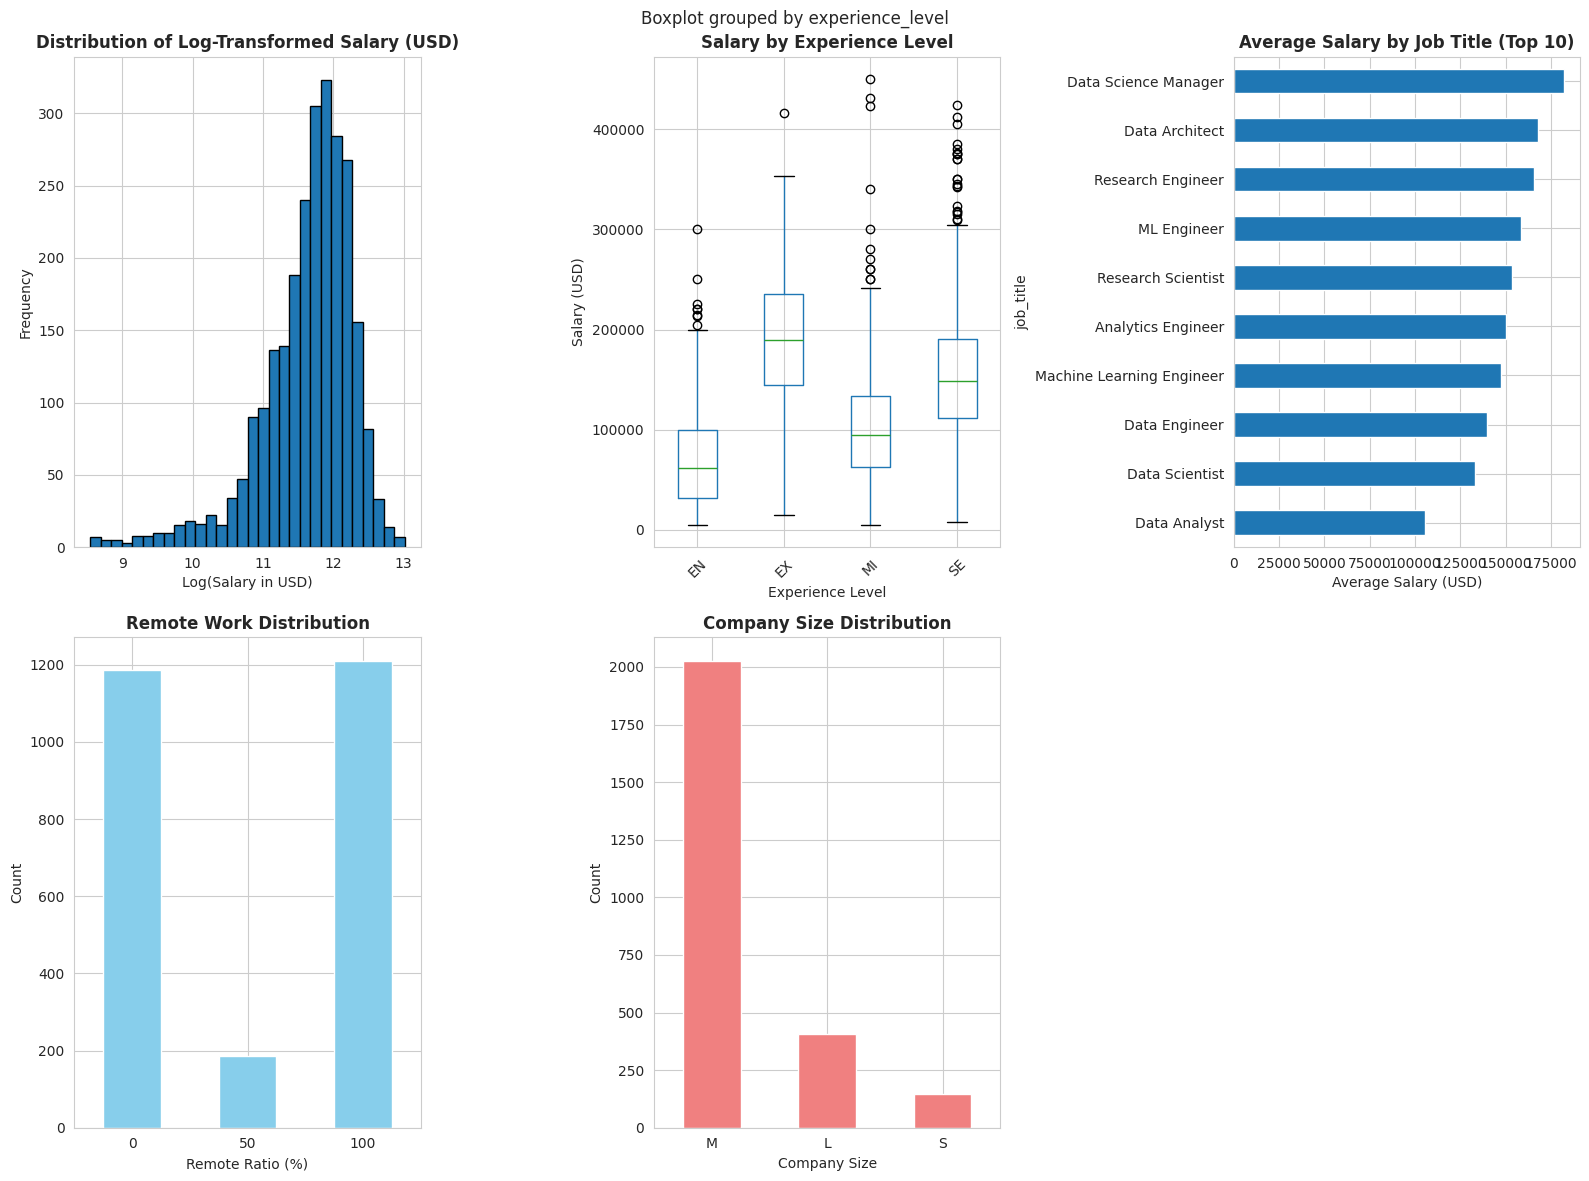

✓ Visualization 2 saved: eda_visualizations_2.png


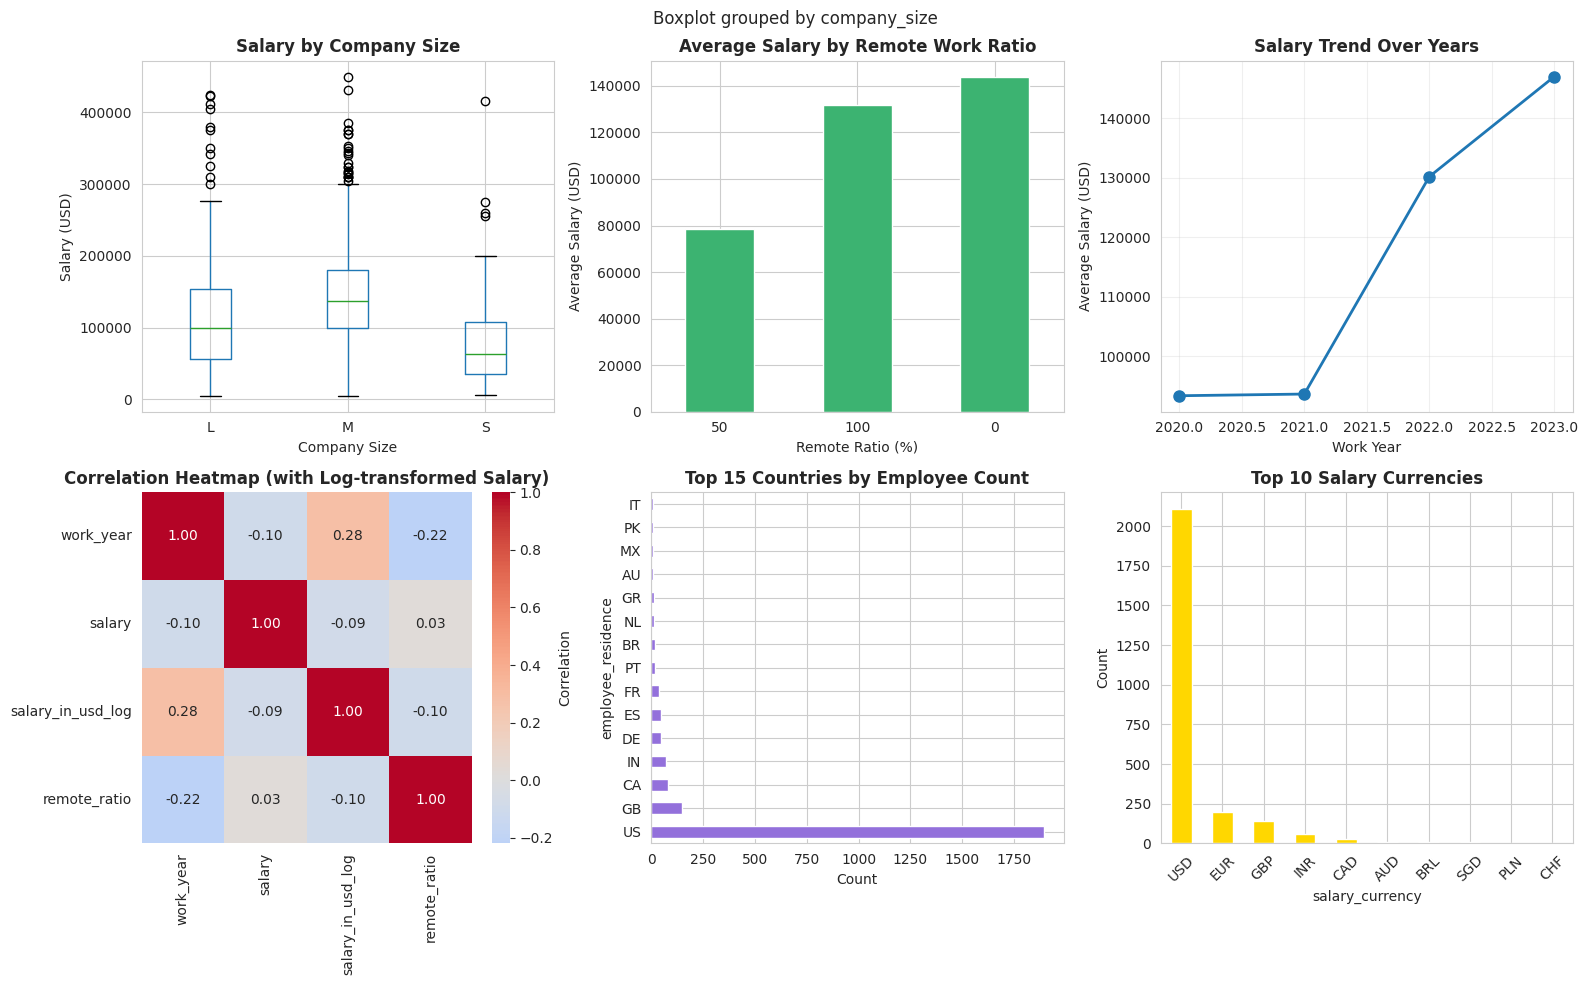


--- 3.5: KEY INSIGHTS ---

📊 Dataset Overview:
  • Total records: 2,584
  • Time period: 2020 - 2023
  • Countries represented: 78
  • Job titles: 93

💰 Salary Insights:
  • Average salary (USD): $133,409.28
  • Median salary (USD): $130,000.00
  • Salary range: $5,132 - $450,000
  • Highest paying job: Research Scientist
  • Highest paying country: IL

👔 Employment Insights:
  • Most common role: Data Engineer
  • Full-time employees: 2547 (98.6%)
  • Remote work ratio: 50% (average)
  • Most common company size: M

🏂 Company Insights:
  • Highest average salary by size: M ($141,475)

3.6: DETAILED INSIGHTS FROM VISUALIZATIONS

--- VISUALIZATION 1: SALARY DISTRIBUTION & DEMOGRAPHICS ---

1‼️ Distribution of Log-Transformed Salary (USD):
   • The log-transformed distribution shows a relatively balanced pattern
   • Skewness coefficient (log-transformed): -1.466
   • 25th percentile (log-transformed): 11.35
   • 75th percentile (log-transformed): 12.07
   • Interquartile range (IQR) (l

In [ ]:
if __name__ == "__main__":
    # Download latest version
    dataset_path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")
    print("Path to dataset files:", dataset_path)

    # Construct the full path to the CSV file
    filepath = os.path.join(dataset_path, 'ds_salaries.csv')

    try:
        # Step 1: Load and Overview
        df = load_and_overview_data(filepath)

        # Step 2: Preprocessing
        df_processed = data_preprocessing(df)

        # Step 3: Exploratory Data Analysis
        df_final = exploratory_data_analysis(df_processed)

        # Save processed dataset
        df_processed.to_csv('ds_salaries_processed.csv', index=False)
        print("\n✓ Processed dataset saved as 'ds_salaries_processed.csv'")

        print("\n" + "=" * 80)
        print("ANALYSIS COMPLETE!")
        print("=" * 80)

    except FileNotFoundError:
        print(f"Error: {filepath} not found. Please ensure the dataset is downloaded correctly.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")